In [184]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# =======================================================
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
# =======================================================
# BƯỚC 1: ĐỌC VÀ MÔ TẢ DỮ LIỆU
# Đọc file CSV
df = pd.read_csv('E:\\smartphones_data.csv.csv')

# Kiểm tra kích thước và liệt kê các cột
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())

# Kiểm tra kiểu dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())

Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   object 
 1   Name                  3260 non-null   object 
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   object 
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null 

In [185]:
df = df.drop_duplicates()
print(f"\nKích thước sau khi xóa dữ liệu trùng lặp: {df.shape[0]} dòng, {df.shape[1]} cột")


Kích thước sau khi xóa dữ liệu trùng lặp: 3260 dòng, 20 cột


In [186]:
# BƯỚC 2: PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU LỖI
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())


Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [187]:
# Xử lý giá trị thiếu (missing values)
# điền median (trung vị) cho các cột số và mode (yếu tố xuất hiện nhiều nhất) cho cột phân loại

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Xử lý giá trị không hợp lệ & dị thường
# Giá RAM, storage, Battery_cap không được âm hoặc bằng 0
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]

# Số lượng camera không được bằng 0
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]

# Kích thước màn hình <= 8 inch
df = df[df['display_size(inch)'] <= 8]


# Xử lý kiểu dữ liệu các biến Categorical Yes/No -> 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Xử lý cột OS
# Gom thành 3 nhóm rõ ràng: 'android', 'ios', và 'other'
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')

In [188]:
# BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ
# =======================================================
print("\n--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---")

# Lọc ra các cột dạng số (để tránh describe cả các cột chữ)
numeric_cols_for_desc = df.select_dtypes(include=[np.number])

summary_stats = numeric_cols_for_desc.describe().round(2)

print(summary_stats)


--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---
           Price      RAM  storage  Battery_cap  has_fast_charging  \
count    3259.00  3259.00  3259.00      3259.00            3259.00   
mean    20138.48     5.06   111.92      4163.01               0.47   
std     24024.50     3.25   126.72      1312.33               0.50   
min      2500.00     0.25     0.31      1100.00               0.00   
25%      7490.00     3.00    32.00      3005.00               0.00   
50%     11999.00     4.00    64.00      4500.00               0.00   
75%     21999.00     8.00   128.00      5000.00               1.00   
max    200999.00    24.00  1024.00     22000.00               1.00   

       has_fingerprints  has_nfc   has_5g  num_core  primery_rear_camera  \
count           3259.00  3259.00  3259.00   3259.00              3259.00   
mean               0.96     0.26     0.31      7.14                32.65   
std                0.20     0.44     0.46      1.65                29.40   
min                

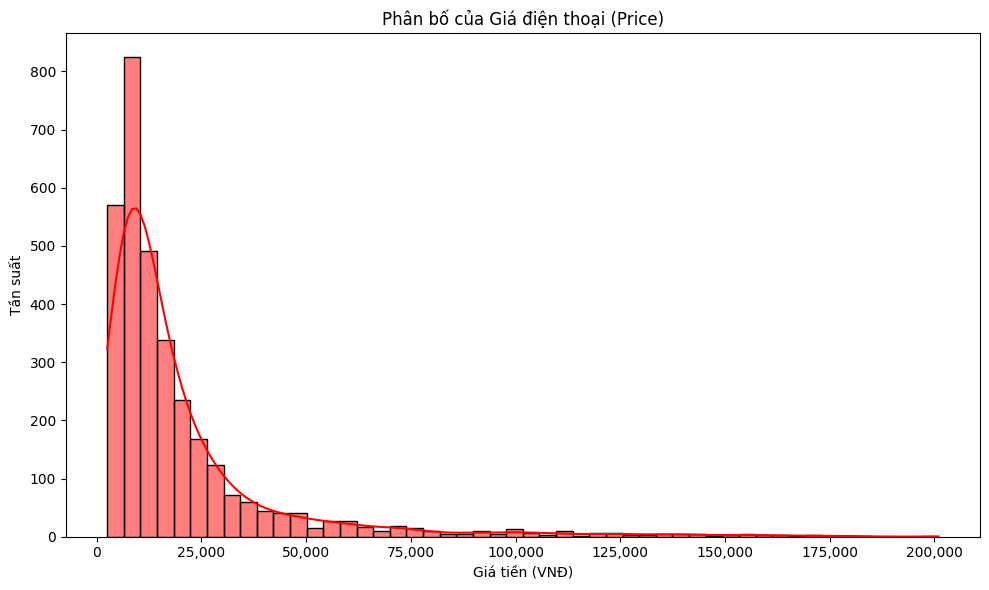

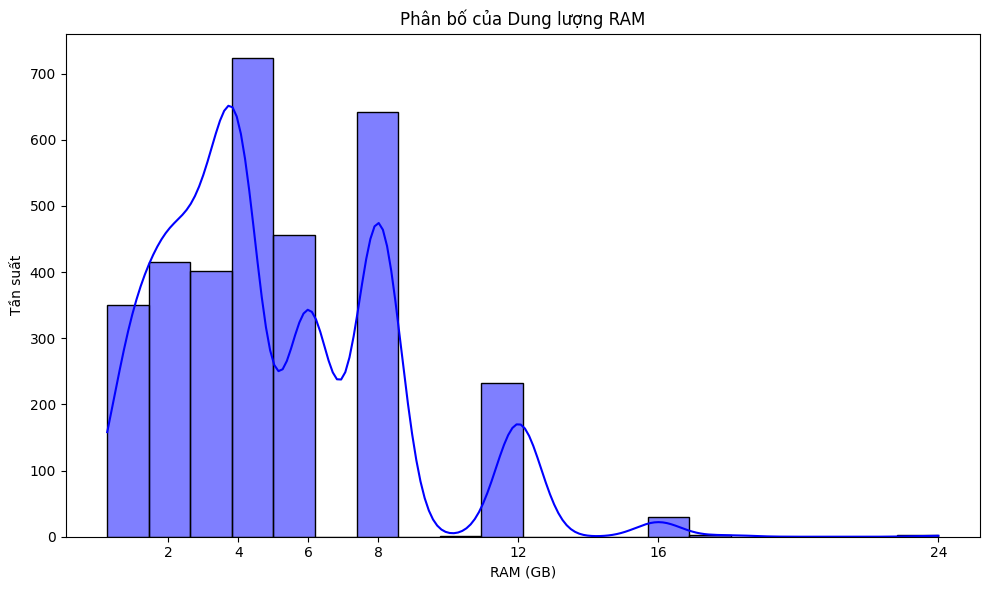

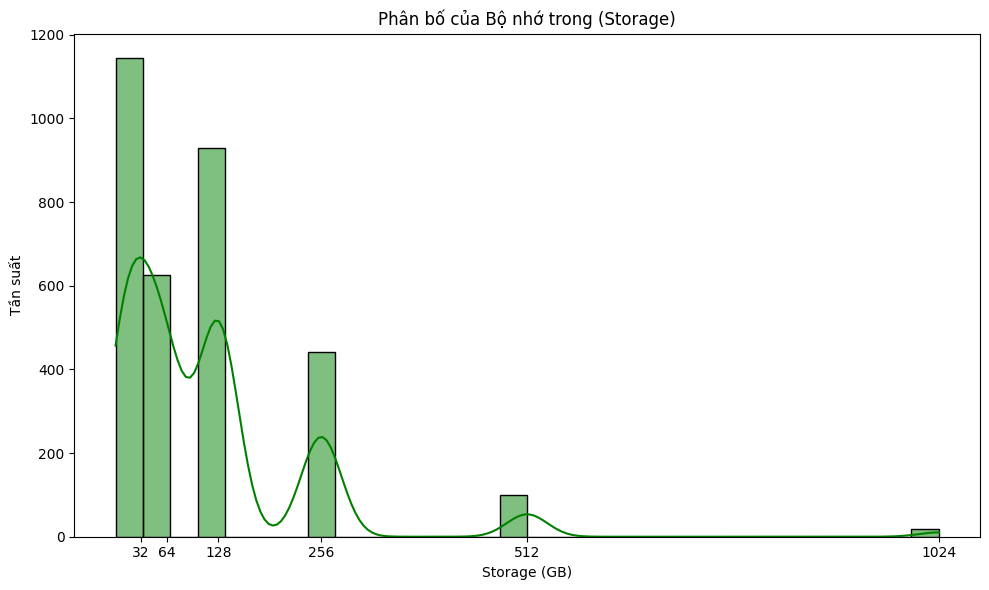

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Thiết lập style đồ thị
sns.set_theme(style="whitegrid")
plt.style.use('default')

# Hàm định dạng dấu phẩy hàng nghìn
comma_formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

# 1. Biểu đồ Giá điện thoại (Price)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price', kde=True, color='red', bins=50, edgecolor='black')
plt.gca().xaxis.set_major_formatter(comma_formatter) # Thêm dấu phẩy hàng nghìn
plt.title('Phân bố của Giá điện thoại (Price)')
plt.xlabel('Giá tiền (VNĐ)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 2. Biểu đồ Dung lượng RAM
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RAM', kde=True, color='blue', bins=20, edgecolor='black')
plt.xticks([2, 4, 6, 8, 12, 16, 24]) # Ép hiển thị đúng các mốc RAM
plt.title('Phân bố của Dung lượng RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 3. Biểu đồ Bộ nhớ trong (Storage)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='storage', kde=True, color='green', bins=30, edgecolor='black')
plt.xticks([32, 64, 128, 256, 512, 1024]) # Ép hiển thị đúng các mốc ROM
plt.title('Phân bố của Bộ nhớ trong (Storage)')
plt.xlabel('Storage (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


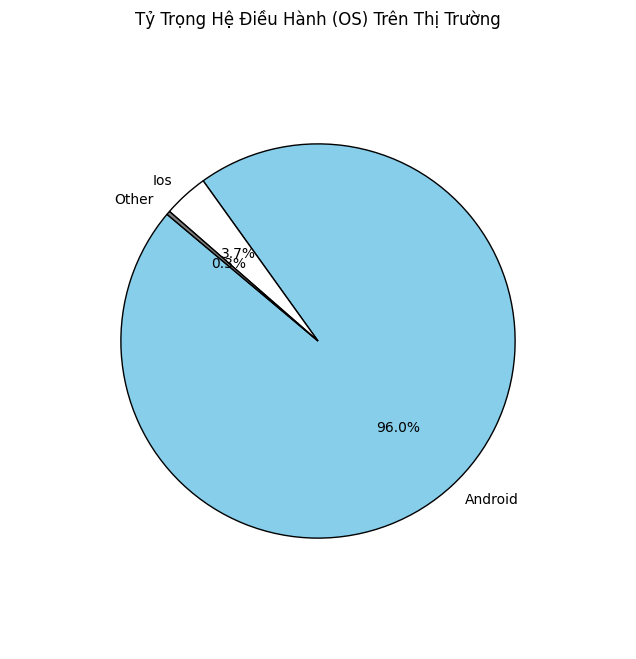

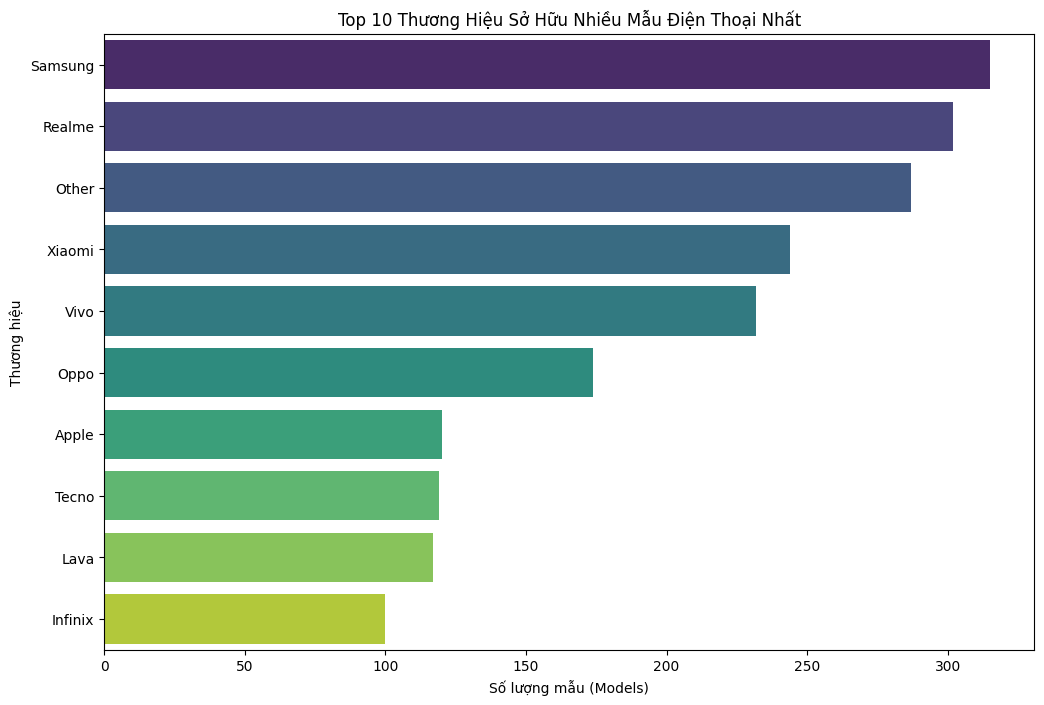

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.style.use('default')

# 1. Hệ điều hành (OS)
plt.figure(figsize=(10, 8))
os_counts = df['OS'].value_counts()
plt.pie(os_counts.values, labels=[label.title() for label in os_counts.index],
        autopct='%1.1f%%', startangle=140, radius=0.8, # Thêm radius=0.8 để thu nhỏ biểu đồ tròn
        colors=['skyblue', 'white', 'gray'],
        wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ Trọng Hệ Điều Hành (OS) Trên Thị Trường')
plt.show()

# 2. Thương hiệu (Brand)
plt.figure(figsize=(12, 8))
top_brands = df['brand_name'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=[str(x).title() for x in top_brands.index], palette="viridis")
plt.title('Top 10 Thương Hiệu Sở Hữu Nhiều Mẫu Điện Thoại Nhất')
plt.xlabel('Số lượng mẫu (Models)')
plt.ylabel('Thương hiệu')
plt.show()

In [191]:
# BƯỚC 3: CHUYỂN ĐỔI DỮ LIỆU VỀ DẠNG PHÙ HỢP

# Bỏ cột 'Name'
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# One-Hot Encoding cho biến categorical: brand_name, processor_brand, display_types
cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Ép kiểu boolean True/False từ get_dummies về dạng 1/0 (số nguyên)
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)

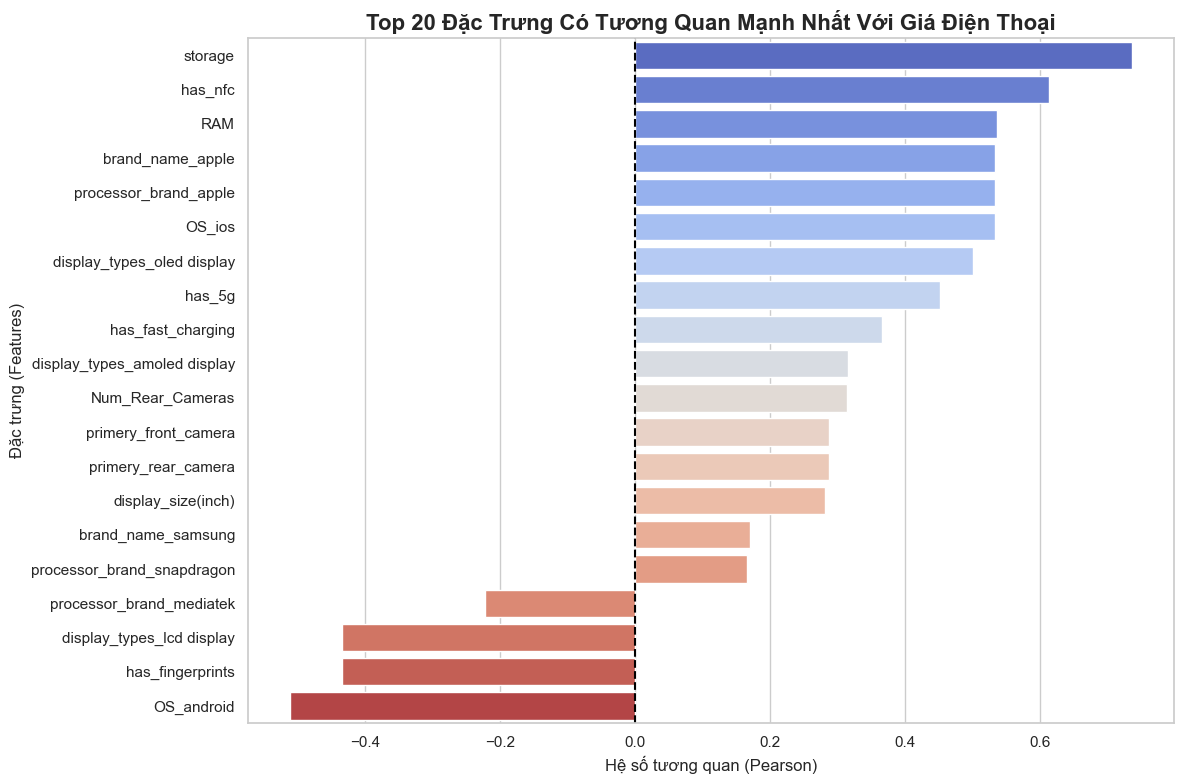

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style="whitegrid")

# Tăng chiều cao lên 8 hoặc 10 để chữ có không gian thở
plt.figure(figsize=(12, 8))

# Lọc các biến dạng số
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Tính tương quan với cột 'Price'
corr_with_price = numeric_df.corr()['Price'].drop('Price')

# BƯỚC MỚI: Chỉ lấy Top 20 biến có sức ảnh hưởng mạnh nhất (trị tuyệt đối lớn nhất)
top_features = corr_with_price.abs().nlargest(20).index

# Lọc lại data theo top_features và sắp xếp từ cao xuống thấp để vẽ
corr_filtered = corr_with_price[top_features].sort_values(ascending=False)

# Vẽ biểu đồ thanh ngang
sns.barplot(x=corr_filtered.values, y=corr_filtered.index, palette='coolwarm')

plt.title('Top 20 Đặc Trưng Có Tương Quan Mạnh Nhất Với Giá Điện Thoại', fontsize=16, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')

# Chỉnh lại layout cho gọn
plt.tight_layout()
plt.show()

In [193]:
# BƯỚC 4: CHUẨN HÓA GIÁ TRỊ
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột Numeric đầu vào, không chuẩn hóa đầu ra (Price) và các cột Binary (0/1)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

# Thực hiện chuẩn hóa Z-score: z = (x-mean)/s
df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\n Kích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())
print(df.describe())


 Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0        

Kích thước dữ liệu gốc: (3259, 70)


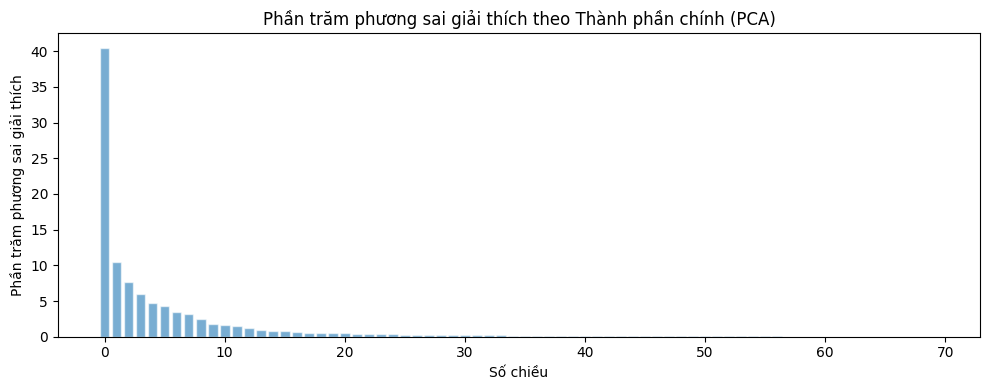

In [194]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# GIẢM CHIỀU BẰNG 2 PHƯƠNG PHÁP (PCA & LDA)
X = df.drop(columns=['Price'])
y = df['Price']

# Tạo y_class (phân loại giá thành 3 nhóm)
y_class = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# Giảm chiều bằng LDA (2 chiều)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_class)

# Giảm chiều bằng PCAA
pca = PCA()
X_pca = pca.fit_transform(X)


plt.style.use('default')
# Lấy mảng tỷ lệ phương sai của từng cột và nhân 100 để ra phần trăm (%)
explained_variance_pct = pca.explained_variance_ratio_ * 100

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(10, 4))

plt.bar(
    range(len(explained_variance_pct)),
    explained_variance_pct,
    alpha=0.6,
    color='tab:blue',
    edgecolor='white'
)

plt.xlabel('Số chiều')
plt.ylabel('Phần trăm phương sai giải thích')
plt.title('Phần trăm phương sai giải thích theo Thành phần chính (PCA)')

plt.tight_layout()
plt.show()

In [195]:
# 1. Tính % mất mát thông tin khi chỉ dùng 4 thành phần chính (PC1 -> PC4)
retained_variance_4pcs = np.sum(pca.explained_variance_ratio_[:4]) * 100
loss_variance_4pcs = 100 - retained_variance_4pcs

print("\n" + "="*50)
print(f"Thông tin giữ lại (4 PC đầu): {retained_variance_4pcs:.2f}%")
print(f"Phần trăm thông tin mất mát (khi dùng 4 PC đầu): {loss_variance_4pcs:.2f}%")
print("="*50)

# 2. Tìm các biến (features) ảnh hưởng nhất đến từng thành phần (PC1 đến PC4)
# pca.components_ chứa ma trận trọng số (mỗi hàng là 1 PC, mỗi cột tương ứng với 1 biến gốc)
feature_names = X.columns
n_pcs = 4           # Số lượng PC muốn kiểm tra (4 PC đầu)
top_n_features = 3  # Số lượng biến top đầu muốn hiển thị cho mỗi PC

print("\nCÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):")

for i in range(n_pcs):
    # Dùng trị tuyệt đối để đánh giá độ lớn của sức ảnh hưởng (bất kể tỷ lệ thuận hay nghịch)
    importance = np.abs(pca.components_[i])

    # Lấy ra index của top các biến có sức ảnh hưởng lớn nhất
    top_indices = np.argsort(importance)[::-1][:top_n_features]

    print(f"\n[PC{i+1}] (giải thích {pca.explained_variance_ratio_[i]*100:.2f}% phương sai):")
    for rank, idx in enumerate(top_indices):
        feature = feature_names[idx]
        weight = pca.components_[i][idx] # Lấy lại trọng số gốc để xem chiều tác động (+ hay -)
        print(f"   {rank+1}. {feature:<20} | Trọng số: {weight:.4f}")


Thông tin giữ lại (4 PC đầu): 64.69%
Phần trăm thông tin mất mát (khi dùng 4 PC đầu): 35.31%

CÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):

[PC1] (giải thích 40.46% phương sai):
   1. RAM                  | Trọng số: 0.3868
   2. display_size(inch)   | Trọng số: 0.3661
   3. Num_Rear_Cameras     | Trọng số: 0.3477

[PC2] (giải thích 10.53% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6274
   2. Battery_cap          | Trọng số: -0.3245
   3. storage              | Trọng số: 0.3082

[PC3] (giải thích 7.67% phương sai):
   1. num_front_camera     | Trọng số: 0.9333
   2. refresh_rate(hz)     | Trọng số: -0.2373
   3. num_core             | Trọng số: 0.1325

[PC4] (giải thích 6.02% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6148
   2. num_core             | Trọng số: 0.5400
   3. storage              | Trọng số: -0.3536


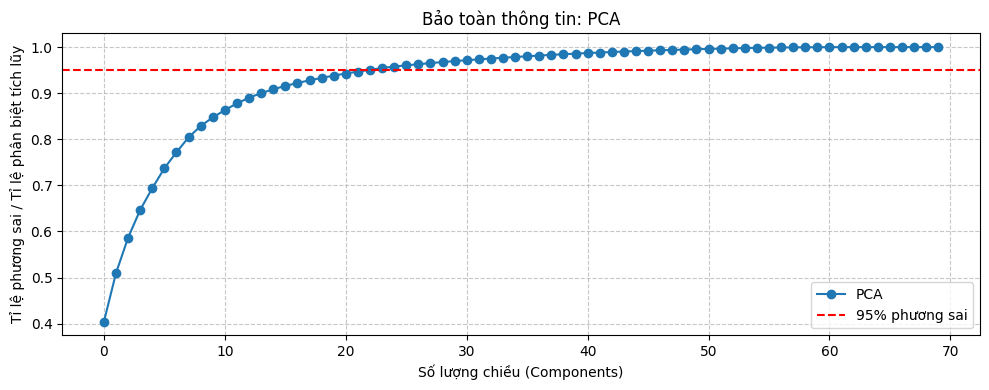

Số chiều chính xác cần để đạt >= 95% phương sai là: 23


In [196]:
plt.figure(figsize=(10, 4))

# Tính toán mảng phương sai tích lũy
pca_variance = np.cumsum(pca.explained_variance_ratio_)

# Vẽ đồ thị
plt.plot( pca_variance, marker='o', label='PCA')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% phương sai')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai / Tỉ lệ phân biệt tích lũy')
plt.title('Bảo toàn thông tin: PCA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Số chiều chính xác cần để đạt >= 95% phương sai là: {n_components_95}")

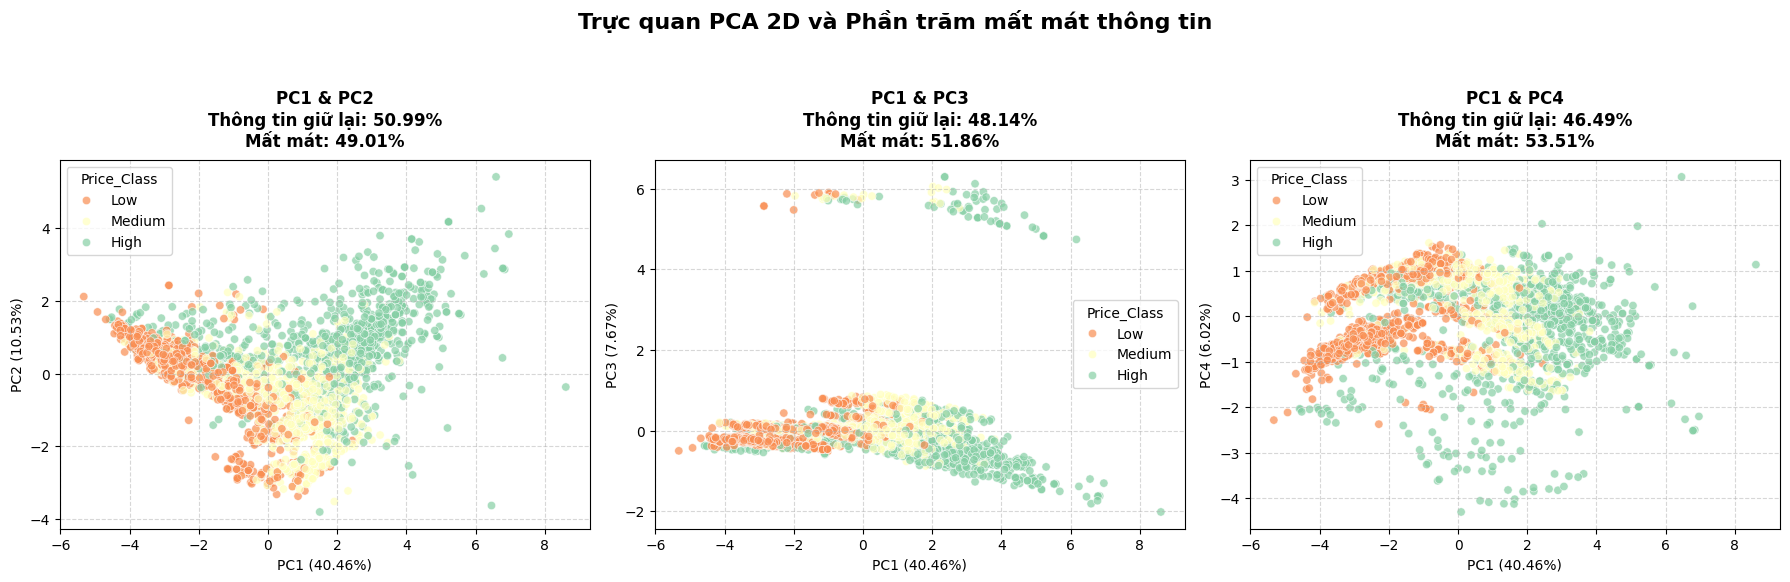

In [197]:
# Tạo DataFrame cho 4 thành phần chính đầu tiên
df_pca = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Price_Class'] = y_class.values

# Lấy tỷ lệ phương sai (phần trăm) của từng thành phần
var_ratios = pca.explained_variance_ratio_ * 100

# Khai báo các cặp trục cần vẽ: (Tên trục X, Tên trục Y, Chỉ số cột X, Chỉ số cột Y)
pairs = [
    ('PC1', 'PC2', 0, 1),
    ('PC1', 'PC3', 0, 2),
    ('PC1', 'PC4', 0, 3)
]

# Tạo 3 khung hình nằm ngang (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, (col_x, col_y, idx_x, idx_y) in enumerate(pairs):
    # Tính toán thông tin giữ lại và mất mát
    retained_info = var_ratios[idx_x] + var_ratios[idx_y]
    loss_info = 100 - retained_info

    # Vẽ Scatter Plot trên từng khung hình (axes[i])
    sns.scatterplot(
        data=df_pca,
        x=col_x,
        y=col_y,
        hue='Price_Class',
        palette='Spectral',
        alpha=0.7,
        ax=axes[i]
    )

    # Cấu hình tiêu đề và chú thích
    title = f"{col_x} & {col_y}\nThông tin giữ lại: {retained_info:.2f}%\nMất mát: {loss_info:.2f}%"
    axes[i].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Tùy chỉnh nhãn trục X, Y để hiển thị rõ mỗi trục mang bao nhiêu %
    axes[i].set_xlabel(f"{col_x} ({var_ratios[idx_x]:.2f}%)")
    axes[i].set_ylabel(f"{col_y} ({var_ratios[idx_y]:.2f}%)")

# Thêm tiêu đề tổng cho toàn bộ Figure
plt.suptitle('Trực quan PCA 2D và Phần trăm mất mát thông tin', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

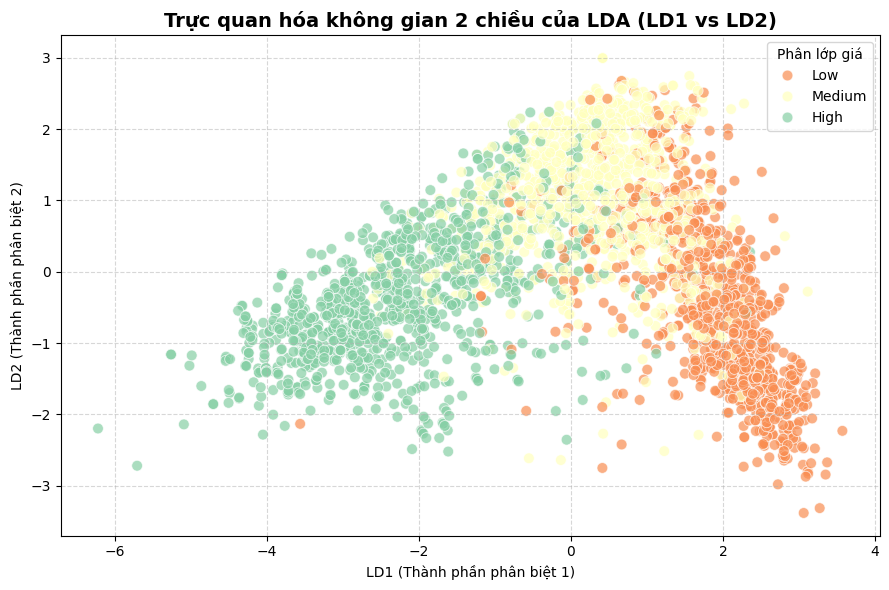

In [198]:
plt.figure(figsize=(9, 6))

# Tạo DataFrame chứa cả LD1, LD2 và nhãn class
df_lda_2d = pd.DataFrame({
    'LD1': X_lda[:, 0],
    'LD2': X_lda[:, 1],
    'Price_Class': y_class
})

# Vẽ biểu đồ Scatter 2D
sns.scatterplot(
    data=df_lda_2d,
    x='LD1',
    y='LD2',
    hue='Price_Class',
    palette='Spectral',
    alpha=0.7,
    s=60, # kích thước điểm ảnh
    edgecolor='w'
)

plt.title('Trực quan hóa không gian 2 chiều của LDA (LD1 vs LD2)', fontsize=14, fontweight='bold')
plt.xlabel('LD1 (Thành phần phân biệt 1)')
plt.ylabel('LD2 (Thành phần phân biệt 2)')
plt.legend(title='Phân lớp giá')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

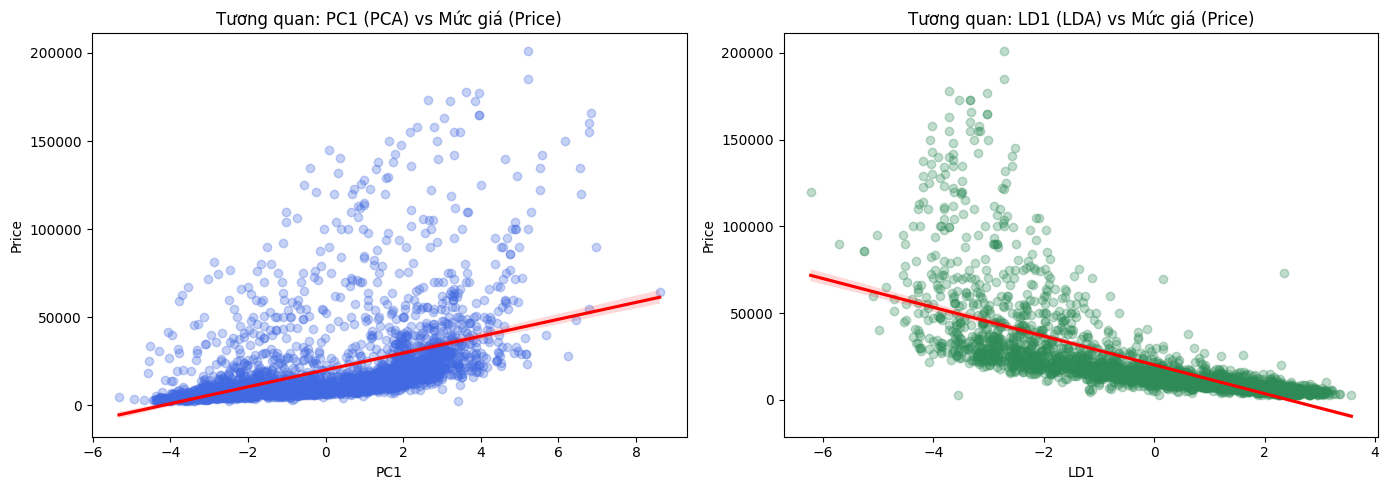

In [199]:
# MỐI QUAN HỆ CHIỀU CHÍNH VỚI ĐẦU RA (TƯƠNG QUAN TUYẾN TÍNH)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 của PCA với Price thực tế
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0], scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Price')

# LD1 của LDA với Price thực tế
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1], scatter_kws={'alpha':0.3, 'color': 'seagreen'}, line_kws={'color':'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 1.3. Phân tích hồi quy




Số chiều sau khi giảm 1/3: 23
Phương sai giải thích: 95.08%

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---
Model              | Tỉ lệ | MAE Gốc (Train/Test)   | MSE Gốc (Train/Test)   | R2 Gốc (Train/Test)  | MAE PCA (Train/Test)   | MSE PCA (Train/Test)   | R2 PCA (Train/Test) 
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Linear Regression  | 8:2   | 6785 / 7229            | 113931196 / 133611575  | 0.804 / 0.760        | 6949 / 7512            | 126625745 / 150086316  | 0.782 / 0.731       
                   | 7:3   | 6903 / 7098            | 116515143 / 123622642  | 0.809 / 0.751        | 7079 / 7291            | 130679987 / 135251074  | 0.786 / 0.728       
                   | 6:4   | 7086 / 7142            | 120495895 / 118730860  | 0.807 / 0.766        | 7342 / 7210            | 137003912 / 125173813  | 0.780 / 0.753       
----------------------------------------

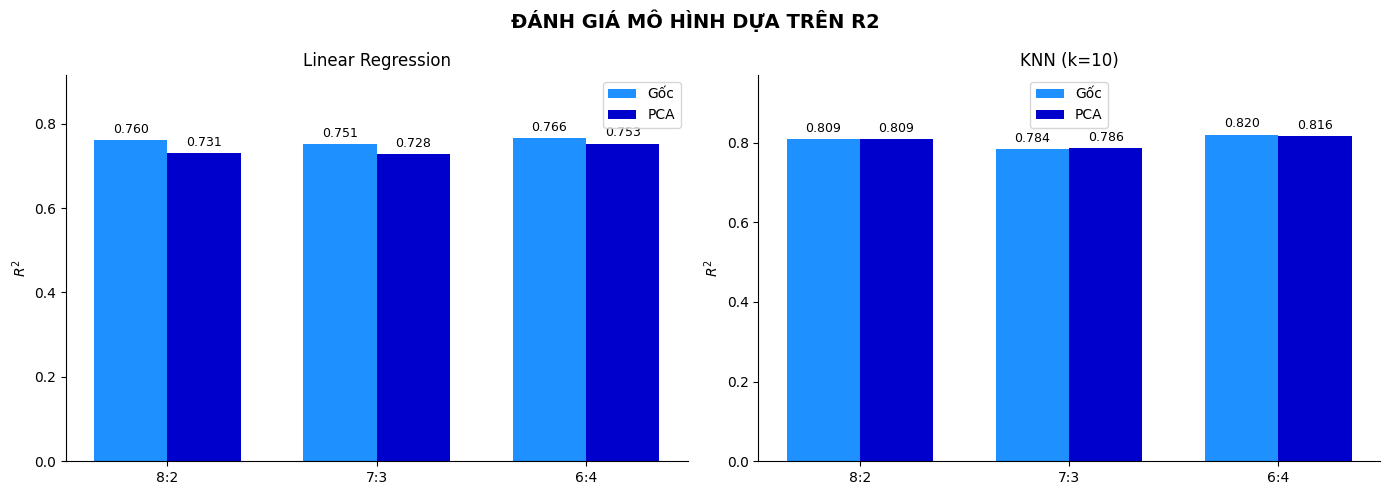

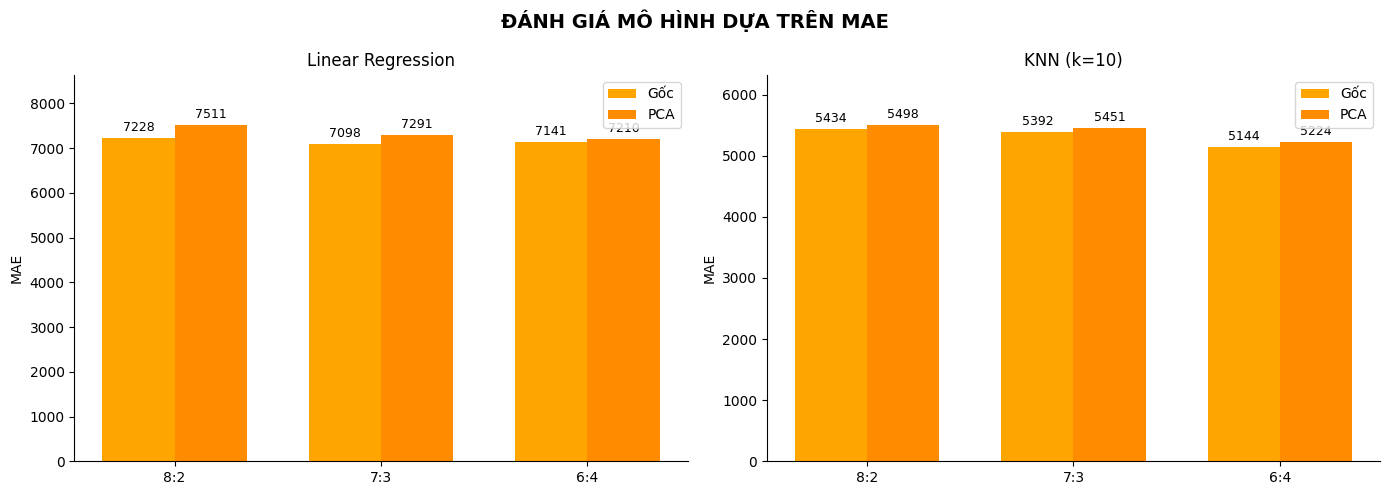

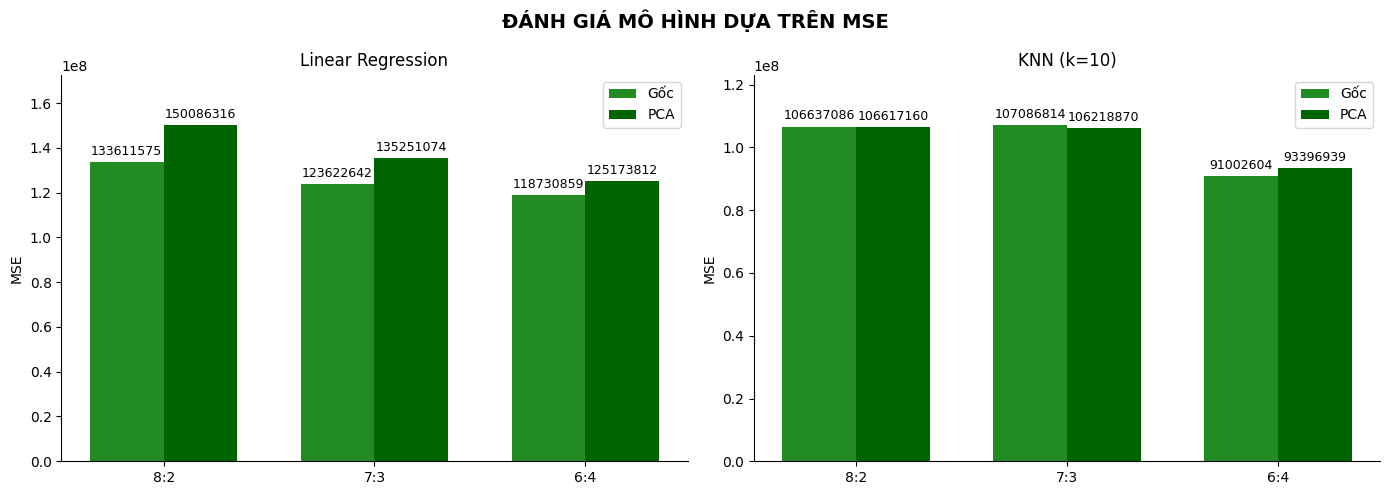

In [210]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# Dữ liệu PCA giảm 1/3 kích thước ban đầu
n_reduced = int(X.shape[1] / 3)
pca = PCA(n_components=n_reduced, random_state=42)
X_reduced = pca.fit_transform(X)
print(f"\nSố chiều sau khi giảm 1/3: {n_reduced}")
print(f"Phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

splits = [0.2, 0.3, 0.4] # test size ứng với 4:1, 7:3, 6:4
models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=10)": KNeighborsRegressor(n_neighbors=10)
}
saved_results = {}

# --- BIẾN LƯU TRỮ DỮ LIỆU VẼ BIỂU ĐỒ (ĐÃ THÊM MSE) ---
lr_r2_goc, lr_r2_pca, lr_mae_goc, lr_mae_pca, lr_mse_goc, lr_mse_pca = [], [], [], [], [], []
knn_r2_goc, knn_r2_pca, knn_mae_goc, knn_mae_pca, knn_mse_goc, knn_mse_pca = [], [], [], [], [], []

print("--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
# Giữ nguyên cấu trúc, chèn thêm MSE
header = f"{'Model':<18} | {'Tỉ lệ':<5} | {'MAE Gốc (Train/Test)':<22} | {'MSE Gốc (Train/Test)':<22} | {'R2 Gốc (Train/Test)':<20} | {'MAE PCA (Train/Test)':<22} | {'MSE PCA (Train/Test)':<22} | {'R2 PCA (Train/Test)':<20}"
print(header)
print("-" * len(header))

# Vòng lặp duyệt Model và Tỉ lệ
for name, model in models.items():
    first_row = True

    for split in splits:
        ratio_str = f"{int((1-split)*10)}:{int(split*10)}"

        # Chia dữ liệu
        X_train_ori, X_test_ori, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
        X_train_red, X_test_red, _, _ = train_test_split(X_reduced, y, test_size=split, random_state=42)

        # Trích xuất trên tập gốc
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test = model.predict(X_test_ori)

        mae_ori_train = mean_absolute_error(y_train, pred_ori_train)
        mae_ori_test = mean_absolute_error(y_test, pred_ori_test)
        mse_ori_train = mean_squared_error(y_train, pred_ori_train)
        mse_ori_test = mean_squared_error(y_test, pred_ori_test)
        r2_ori_train = r2_score(y_train, pred_ori_train)
        r2_ori_test = r2_score(y_test, pred_ori_test)

        # Trích xuất trên tập PCA
        model.fit(X_train_red, y_train)
        pred_red_train = model.predict(X_train_red)
        pred_red_test = model.predict(X_test_red)

        mae_red_train = mean_absolute_error(y_train, pred_red_train)
        mae_red_test = mean_absolute_error(y_test, pred_red_test)
        mse_red_train = mean_squared_error(y_train, pred_red_train)
        mse_red_test = mean_squared_error(y_test, pred_red_test)
        r2_red_train = r2_score(y_train, pred_red_train)
        r2_red_test = r2_score(y_test, pred_red_test)

        # Lưu kết quả trường hợp 4:1
        if split == 0.2:
            saved_results[name] = {"y_test": y_test, "y_pred": pred_ori_test}

        # Lưu dữ liệu để vẽ biểu đồ
        if name == "Linear Regression":
            lr_r2_goc.append(r2_ori_test)
            lr_r2_pca.append(r2_red_test)
            lr_mae_goc.append(mae_ori_test)
            lr_mae_pca.append(mae_red_test)
            lr_mse_goc.append(mse_ori_test)
            lr_mse_pca.append(mse_red_test)
        elif name == "KNN (k=10)":
            knn_r2_goc.append(r2_ori_test)
            knn_r2_pca.append(r2_red_test)
            knn_mae_goc.append(mae_ori_test)
            knn_mae_pca.append(mae_red_test)
            knn_mse_goc.append(mse_ori_test)
            knn_mse_pca.append(mse_red_test)

        # In kết quả (Giữ nguyên định dạng, bổ sung biến MSE)
        display_name = name if first_row else ""
        mae_ori_str = f"{mae_ori_train:.0f} / {mae_ori_test:.0f}"
        mse_ori_str = f"{mse_ori_train:.0f} / {mse_ori_test:.0f}"
        r2_ori_str = f"{r2_ori_train:.3f} / {r2_ori_test:.3f}"

        mae_red_str = f"{mae_red_train:.0f} / {mae_red_test:.0f}"
        mse_red_str = f"{mse_red_train:.0f} / {mse_red_test:.0f}"
        r2_red_str = f"{r2_red_train:.3f} / {r2_red_test:.3f}"

        print(f"{display_name:<18} | {ratio_str:<5} | {mae_ori_str:<22} | {mse_ori_str:<22} | {r2_ori_str:<20} | {mae_red_str:<22} | {mse_red_str:<22} | {r2_red_str:<20}")
        first_row = False

    print("-" * len(header))

# =====================================================================
# VẼ BIỂU ĐỒ (CHIA LÀM 3 KHUNG HÌNH THEO TỪNG MỤC R2, MAE, MSE)
# =====================================================================
labels = ['8:2', '7:3', '6:4']
x = np.arange(len(labels))
width = 0.35

plt.style.use('default')

def remove_spines(ax):
    """Hàm phụ trợ để làm sạch viền biểu đồ"""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# MỤC 1: BIỂU ĐỒ SO SÁNH R2
# ---------------------------------------------------------
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('ĐÁNH GIÁ MÔ HÌNH DỰA TRÊN R2', fontsize=14, fontweight='bold')

# LR - R2
rects1 = ax1.bar(x - width/2, lr_r2_goc, width, label='Gốc', color='dodgerblue')
rects2 = ax1.bar(x + width/2, lr_r2_pca, width, label='PCA', color='mediumblue')
ax1.set_ylabel('$R^2$')
ax1.set_title('Linear Regression')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, max(max(lr_r2_goc), max(lr_r2_pca)) + 0.15)
ax1.legend()
ax1.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
ax1.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)
remove_spines(ax1)

# KNN - R2
rects3 = ax2.bar(x - width/2, knn_r2_goc, width, label='Gốc', color='dodgerblue')
rects4 = ax2.bar(x + width/2, knn_r2_pca, width, label='PCA', color='mediumblue')
ax2.set_ylabel('$R^2$')
ax2.set_title('KNN (k=10)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, max(max(knn_r2_goc), max(knn_r2_pca)) + 0.15)
ax2.legend()
ax2.bar_label(rects3, padding=3, fmt='%.3f', fontsize=9)
ax2.bar_label(rects4, padding=3, fmt='%.3f', fontsize=9)
remove_spines(ax2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# MỤC 2: BIỂU ĐỒ SO SÁNH MAE
# ---------------------------------------------------------
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH DỰA TRÊN MAE', fontsize=14, fontweight='bold')

# LR - MAE
rects5 = ax3.bar(x - width/2, lr_mae_goc, width, label='Gốc', color='orange')
rects6 = ax3.bar(x + width/2, lr_mae_pca, width, label='PCA', color='darkorange')
ax3.set_ylabel('MAE')
ax3.set_title('Linear Regression')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylim(0, max(max(lr_mae_goc), max(lr_mae_pca)) * 1.15)
ax3.legend()
ax3.bar_label(rects5, padding=3, fmt='%d', fontsize=9)
ax3.bar_label(rects6, padding=3, fmt='%d', fontsize=9)
remove_spines(ax3)

# KNN - MAE
rects7 = ax4.bar(x - width/2, knn_mae_goc, width, label='Gốc', color='orange')
rects8 = ax4.bar(x + width/2, knn_mae_pca, width, label='PCA', color='darkorange')
ax4.set_ylabel('MAE')
ax4.set_title('KNN (k=10)')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_ylim(0, max(max(knn_mae_goc), max(knn_mae_pca)) * 1.15)
ax4.legend()
ax4.bar_label(rects7, padding=3, fmt='%d', fontsize=9)
ax4.bar_label(rects8, padding=3, fmt='%d', fontsize=9)
remove_spines(ax4)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# MỤC 3: BIỂU ĐỒ SO SÁNH MSE
# ---------------------------------------------------------
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('ĐÁNH GIÁ MÔ HÌNH DỰA TRÊN MSE', fontsize=14, fontweight='bold')

# LR - MSE
rects9 = ax5.bar(x - width/2, lr_mse_goc, width, label='Gốc', color='forestgreen')
rects10 = ax5.bar(x + width/2, lr_mse_pca, width, label='PCA', color='darkgreen')
ax5.set_ylabel('MSE')
ax5.set_title('Linear Regression')
ax5.set_xticks(x)
ax5.set_xticklabels(labels)
ax5.set_ylim(0, max(max(lr_mse_goc), max(lr_mse_pca)) * 1.15)
ax5.legend()
ax5.bar_label(rects9, padding=3, fmt='%d', fontsize=9)
ax5.bar_label(rects10, padding=3, fmt='%d', fontsize=9)
remove_spines(ax5)

# KNN - MSE
rects11 = ax6.bar(x - width/2, knn_mse_goc, width, label='Gốc', color='forestgreen')
rects12 = ax6.bar(x + width/2, knn_mse_pca, width, label='PCA', color='darkgreen')
ax6.set_ylabel('MSE')
ax6.set_title('KNN (k=10)')
ax6.set_xticks(x)
ax6.set_xticklabels(labels)
ax6.set_ylim(0, max(max(knn_mse_goc), max(knn_mse_pca)) * 1.15)
ax6.legend()
ax6.bar_label(rects11, padding=3, fmt='%d', fontsize=9)
ax6.bar_label(rects12, padding=3, fmt='%d', fontsize=9)
remove_spines(ax6)

plt.tight_layout()
plt.show()

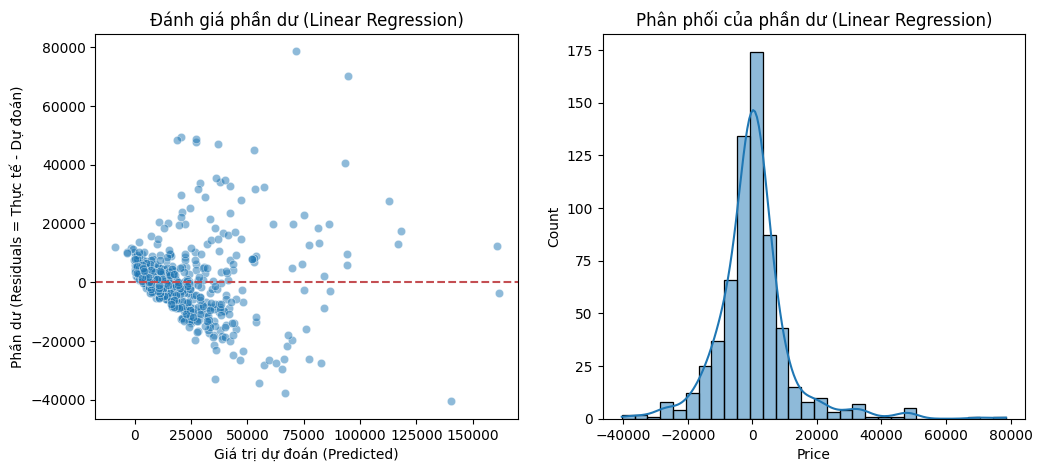

In [201]:
y_test_lr = saved_results["Linear Regression"]["y_test"]
y_pred_lr = saved_results["Linear Regression"]["y_pred"]

# 👉 Tính phần dư
residuals = y_test_lr - y_pred_lr

# Biểu đồ đánh giá phần dư
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán (Predicted)')
plt.ylabel('Phần dư (Residuals = Thực tế - Dự đoán)')
plt.title('Đánh giá phần dư (Linear Regression)')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Phân phối của phần dư (Linear Regression)')
plt.show()

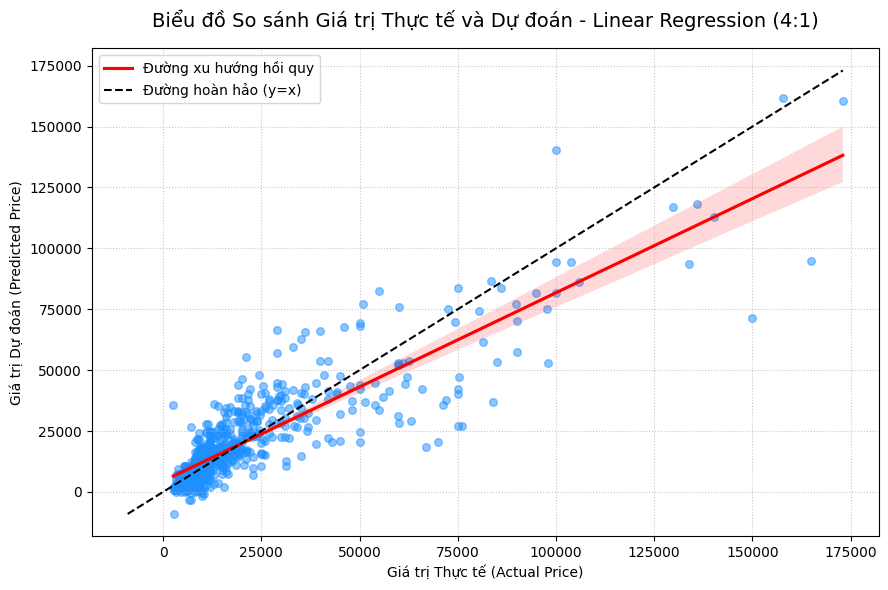

In [202]:
# Biểu đồ thực tế vs dự đoán
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# 1. Vẽ các điểm dữ liệu và đường xu hướng hồi quy
# x là Thực tế (Trục hoành), y là Dự đoán (Trục tung)
sns.regplot(
    x=y_test_lr,
    y=y_pred_lr,
    scatter_kws={'alpha': 0.5, 'color': 'dodgerblue', 's': 30},
    line_kws={'color': 'red', 'label': 'Đường xu hướng hồi quy'}
)

# 2. Vẽ đường hoàn hảo y = x (Nơi Dự đoán chính xác 100% bằng Thực tế)
min_val = min(y_test_lr.min(), y_pred_lr.min())
max_val = max(y_test_lr.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Đường hoàn hảo (y=x)')

# 3. Thêm nhãn và tiêu đề
plt.xlabel('Giá trị Thực tế (Actual Price)')
plt.ylabel('Giá trị Dự đoán (Predicted Price)')
plt.title('Biểu đồ So sánh Giá trị Thực tế và Dự đoán - Linear Regression (4:1)', fontsize=14, pad=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Hiển thị đồ thị
plt.tight_layout()
plt.show()

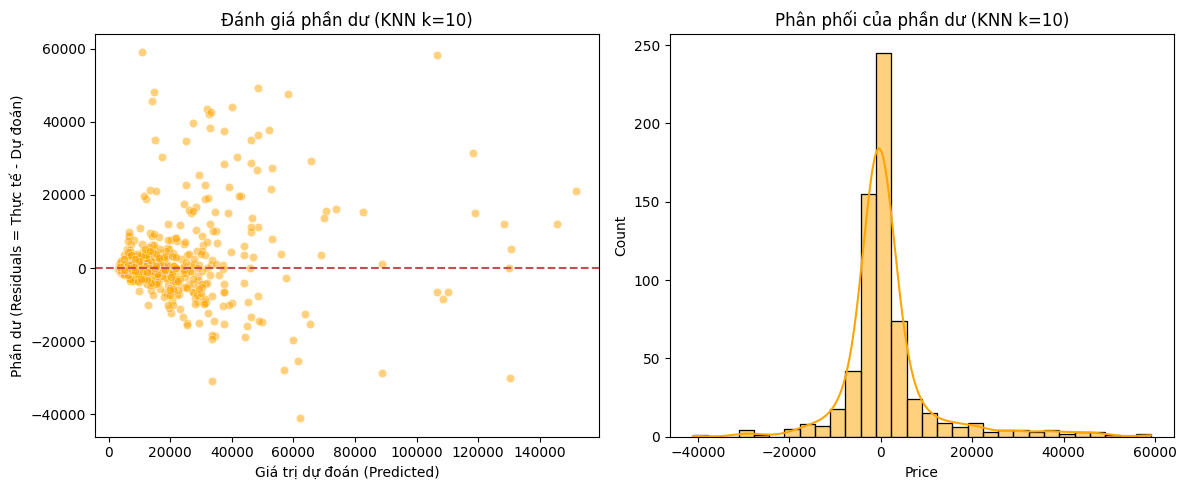

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

# TRÍCH XUẤT DỮ LIỆU CỦA KNN (k=10)
y_test_knn = saved_results["KNN (k=10)"]["y_test"]
y_pred_knn = saved_results["KNN (k=10)"]["y_pred"]

# Tính phần dư
residuals_knn = y_test_knn - y_pred_knn

# 1. Biẻu đồ đánh giá phần dư

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_knn, y=residuals_knn, alpha=0.5, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán (Predicted)')
plt.ylabel('Phần dư (Residuals = Thực tế - Dự đoán)')
plt.title('Đánh giá phần dư (KNN k=10)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_knn, kde=True, bins=30, color='orange')
plt.title('Phân phối của phần dư (KNN k=10)')
plt.tight_layout()
plt.show()


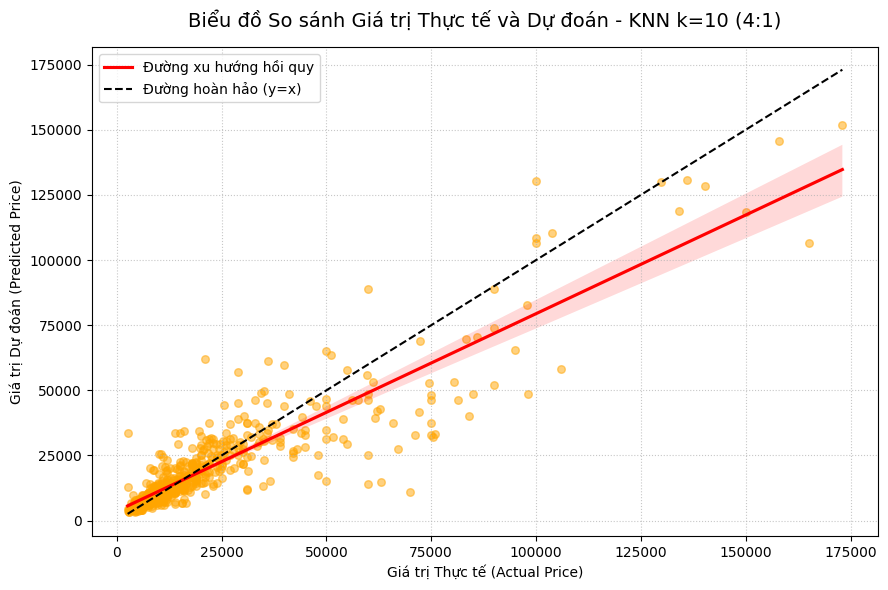

In [204]:
# Biểu đồ thực tế vs dự đoán
plt.figure(figsize=(9, 6))

# Vẽ các điểm dữ liệu và đường xu hướng hồi quy
# Đổi màu scatter thành màu cam để đồng bộ với biểu đồ KNN trước đó
sns.regplot(
    x=y_test_knn,
    y=y_pred_knn,
    scatter_kws={'alpha': 0.5, 'color': 'orange', 's': 30},
    line_kws={'color': 'red', 'label': 'Đường xu hướng hồi quy'}
)

# Vẽ đường hoàn hảo y = x (Nơi Dự đoán chính xác 100% bằng Thực tế)
min_val = min(y_test_knn.min(), y_pred_knn.min())
max_val = max(y_test_knn.max(), y_pred_knn.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Đường hoàn hảo (y=x)')

# Thêm nhãn và tiêu đề
plt.xlabel('Giá trị Thực tế (Actual Price)')
plt.ylabel('Giá trị Dự đoán (Predicted Price)')
plt.title('Biểu đồ So sánh Giá trị Thực tế và Dự đoán - KNN k=10 (4:1)', fontsize=14, pad=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Hiển thị đồ thị
plt.tight_layout()
plt.show()